In [1]:
!git clone https://github.com/yazeedsn/SSL_SimCLR_Experiment.git
%cd SSL_SimCLR_Experiment
!pip install -r requirements.txt
!pip install -e .


fatal: destination path 'SSL_SimCLR_Experiment' already exists and is not an empty directory.
/content/SSL_SimCLR_Experiment
Obtaining file:///content/SSL_SimCLR_Experiment
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ssl-simclr-experiment (pyproject.toml) ... done
  Created wheel for ssl-simclr-experiment: filename=ssl_simclr_experiment-0.1.0-0.editable-py3-none-any.whl size=2823 sha256=d1e36a6130b04bef9816fe4d540ec0e31cc3836d6f8e0da34cbb29c6c5c7be0e
  Stored in directory: /tmp/pip-ephem-wheel-cache-kk70l0zb/wheels/78/ea/43/e8233a028f84e8d0dbb61cc4c0f5e8957ff9dbd664daab8e67
Successfully built ssl-simclr-experiment
  Attempting uninstall: ssl-simclr-experiment
    Found existing installation: ssl-simclr-experiment 0.1.0
    Uninstalling ssl-simclr-experiment-0.1.0:
      Successfully uninstalled ssl-si

In [2]:
import torch
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader
from torch.optim import AdamW

from src.losses import nt_xent
from src.models import SimCLR
from src.eval import evaluate_linear_probe
from src.train import train_linear_probe, train_ssl
from src.utils import plot_metric, plot_image_grid, save_checkpoint
from src.datasets import get_labeled_ds, get_unlabeled_ds, get_eval_ds
from src.transforms import get_random_augmentation_normalized_transform, get_random_augmentation_transform


# Training Baseline Model For Linear Probing

In [5]:
# Create a linear probing model with forzen backbone, only train linear probing layers.
baseline_model = SimCLR()
baseline_model.freeze_encoder()
baseline_model = baseline_model.get_linear_prob(10)

# get the labeled dataset
labeled_ds = get_labeled_ds()
labeled_dl = DataLoader(labeled_ds, batch_size=256, shuffle=True)

# get evaluation dataset
eval_ds = get_eval_ds()
eval_dl = DataLoader(eval_ds, batch_size=256, shuffle=False)

# create an optimizer factory, only trains unfrozen parameters
optimizer_factory = lambda p : AdamW(p, lr=1e-3)

# cross entropy loss
loss_fn = CrossEntropyLoss()

# configs
device = 'cuda' if torch.cuda.is_available() else 'cpu'
n_epochs = 20
baseline_model = baseline_model.to(device)
# training function
loss_hist_baseline, acc_hist_baseline = train_linear_probe(
    baseline_model,
    labeled_dl,
    optimizer_factory,
    loss_fn,
    device,
    n_epochs
)


Epoch [1/20] Batch [20/20]: 100%|██████████| 20/20 [00:15<00:00,  1.28it/s, Loss=1.2875]



Epoch 1 completed — Avg Loss: 1.8606 | Avg Acc: 0.3608



Epoch [2/20] Batch [20/20]: 100%|██████████| 20/20 [00:15<00:00,  1.25it/s, Loss=1.1038]



Epoch 2 completed — Avg Loss: 1.1631 | Avg Acc: 0.6568



Epoch [3/20] Batch [20/20]: 100%|██████████| 20/20 [00:15<00:00,  1.29it/s, Loss=0.9940]


...


Epoch 18 completed — Avg Loss: 0.6378 | Avg Acc: 0.7810



Epoch [19/20] Batch [20/20]: 100%|██████████| 20/20 [00:15<00:00,  1.31it/s, Loss=0.5855]



Epoch 19 completed — Avg Loss: 0.6333 | Avg Acc: 0.7824



Epoch [20/20] Batch [20/20]: 100%|██████████| 20/20 [00:15<00:00,  1.29it/s, Loss=0.6996]


Epoch 20 completed — Avg Loss: 0.6477 | Avg Acc: 0.7774



In [7]:
torch.save(baseline_model.state_dict(), "baseline_model.pth")

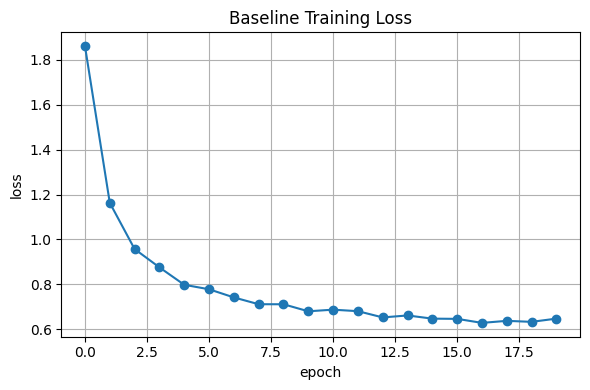

In [8]:
# plot loss
plot_metric(
    loss_hist_baseline,
    list(range(n_epochs)),
    ylabel='loss',
    xlabel='epoch',
    title='Baseline Training Loss',
    save_path='outputs/baseline_loss_curve.png'
)

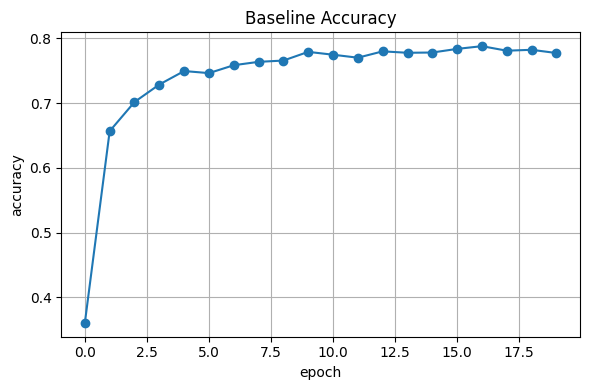

In [9]:
# plot accuracy
plot_metric(
    acc_hist_baseline,
    list(range(n_epochs)),
    ylabel='accuracy',
    xlabel='epoch',
    title='Baseline Accuracy',
    save_path='outputs/baseline_acc_curve.png'
)

In [10]:
eval_acc_baseline = evaluate_linear_probe(baseline_model, eval_dl, len(eval_ds), device)

Test Accuracy: 0.8145


# Training SimCLR Model Encoder

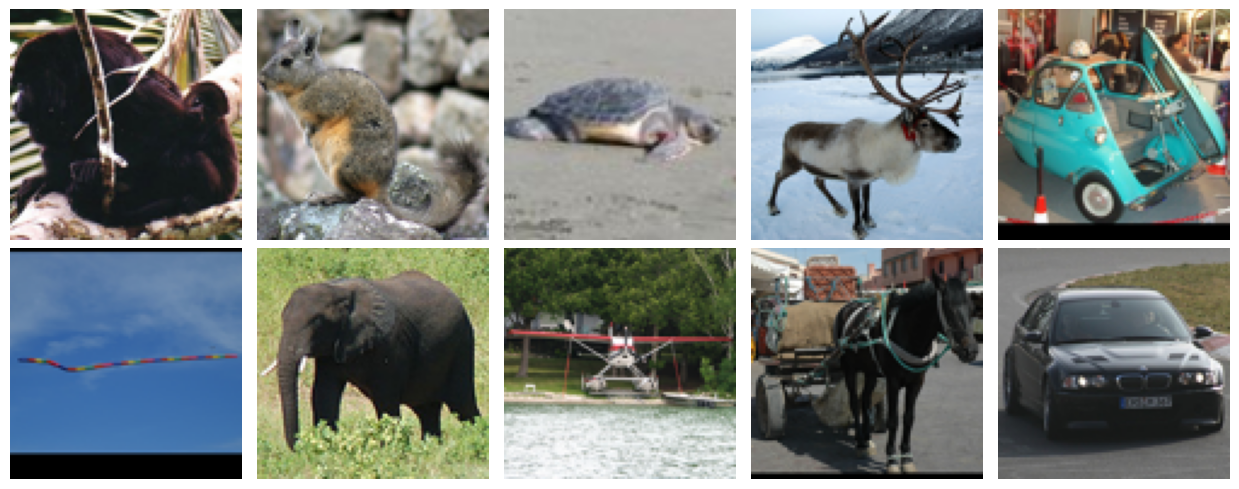

In [11]:
# train represnetions on unlabeled dataset
unlabeled_ds = get_unlabeled_ds()
unlabeled_dl = DataLoader(unlabeled_ds, batch_size=512, shuffle=True)

# perview of the images without augmentations.
imgs, _ = next(iter(unlabeled_dl))
plot_image_grid(imgs, transform=None, save_path='outputs/images_grid.png')


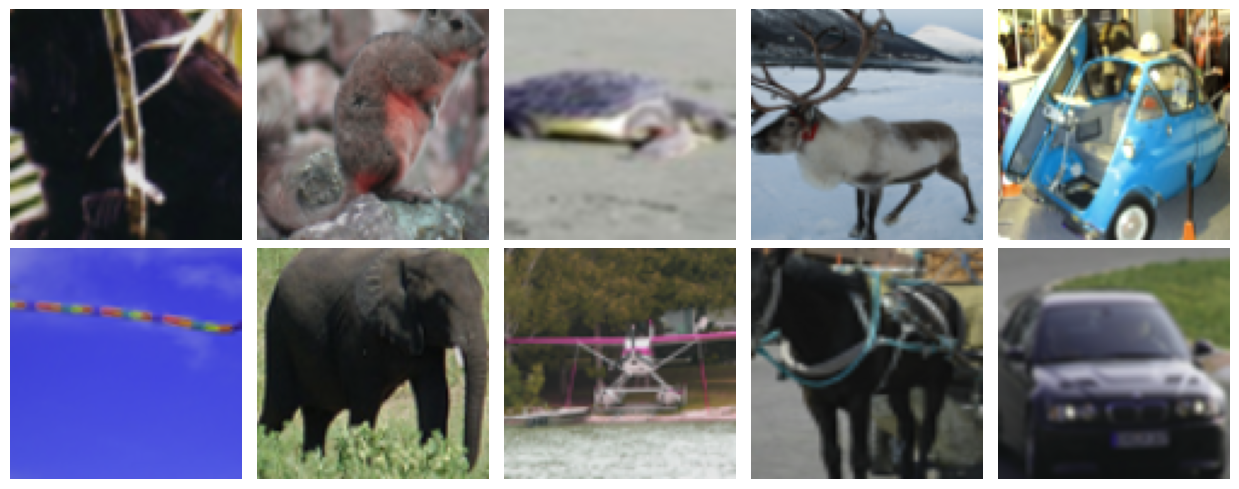

In [12]:
# preview of images with augmentations
tf = get_random_augmentation_transform()
plot_image_grid(imgs, transform=tf, save_path='outputs/images_grid_augmented.png')

In [13]:
simclr_model = SimCLR()
simclr_model.unfreeze_encoder()

optimizer = AdamW(simclr_model.parameters(), lr=3e-3)
loss_fn = nt_xent

aug_transform = get_random_augmentation_normalized_transform()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
n_epochs = 50
simclr_model.to(device)
loss_hist_simclr = train_ssl(
    simclr_model,
    unlabeled_dl,
    optimizer,
    aug_transform,
    loss_fn,
    device,
    n_epochs
)


Epoch [1/50] Loss: 2.5620: 100%|██████████| 196/196 [03:36<00:00,  1.10s/it]



Epoch 1 completed — Avg Loss: 2.5620



Epoch [2/50] Loss: 1.4103: 100%|██████████| 196/196 [03:31<00:00,  1.08s/it]



Epoch 2 completed — Avg Loss: 1.4103



Epoch [3/50] Loss: 0.9917: 100%|██████████| 196/196 [03:30<00:00,  1.07s/it]


...


Epoch 48 completed — Avg Loss: 0.2645



Epoch [49/50] Loss: 0.2183: 100%|██████████| 196/196 [03:33<00:00,  1.09s/it]



Epoch 49 completed — Avg Loss: 0.2183



Epoch [50/50] Loss: 0.2398: 100%|██████████| 196/196 [03:33<00:00,  1.09s/it]


Epoch 50 completed — Avg Loss: 0.2398



In [14]:
torch.save(simclr_model.state_dict(), "simclr_encoder_trained_model.pth")

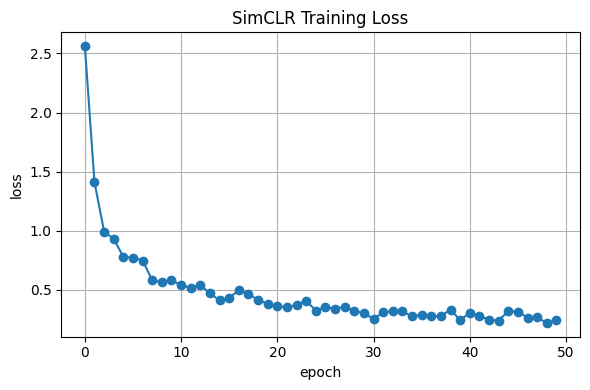

In [16]:
plot_metric(
    loss_hist_simclr,
    list(range(n_epochs)),
    ylabel='loss',
    xlabel='epoch',
    title='SimCLR Training Loss',
    save_path='outputs/simclr_ssl_loss_curve.png'
)

# Training SimCLR For Linear Probing

In [24]:
simclr_model.freeze_encoder()
simclr_model = simclr_model.get_linear_prob(10)

optimizer_factory = lambda p : AdamW(p, lr=1e-3)
loss_fn = CrossEntropyLoss()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
n_epochs = 20
simclr_model = simclr_model.to(device)
loss_hist_simclr_linear_prob, acc_hist_simclr_linear_prob = train_linear_probe(
    simclr_model,
    labeled_dl,
    optimizer_factory,
    loss_fn,
    device,
    n_epochs
)


Epoch [1/20] Batch [20/20]: 100%|██████████| 20/20 [00:19<00:00,  1.01it/s, Loss=1.2771]



Epoch 1 completed — Avg Loss: 1.6186 | Avg Acc: 0.4344



Epoch [2/20] Batch [20/20]: 100%|██████████| 20/20 [00:18<00:00,  1.07it/s, Loss=1.0654]



Epoch 2 completed — Avg Loss: 1.0357 | Avg Acc: 0.6300



Epoch [3/20] Batch [20/20]: 100%|██████████| 20/20 [00:18<00:00,  1.09it/s, Loss=0.9899]


...


Epoch 18 completed — Avg Loss: 0.4084 | Avg Acc: 0.8516



Epoch [19/20] Batch [20/20]: 100%|██████████| 20/20 [00:17<00:00,  1.12it/s, Loss=0.4390]



Epoch 19 completed — Avg Loss: 0.4037 | Avg Acc: 0.8602



Epoch [20/20] Batch [20/20]: 100%|██████████| 20/20 [00:17<00:00,  1.12it/s, Loss=0.4427]


Epoch 20 completed — Avg Loss: 0.3787 | Avg Acc: 0.8590



In [25]:
torch.save(simclr_model.state_dict(), "simclr_linear_prob_trained_model.pth")

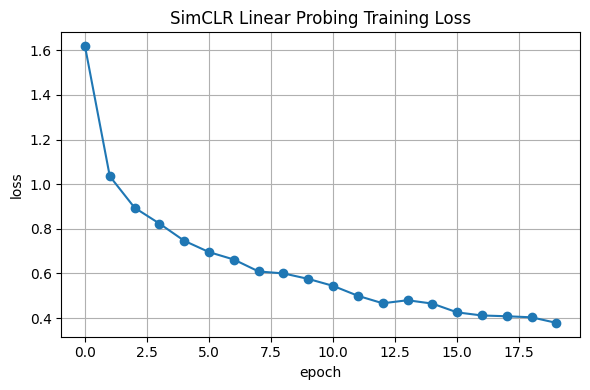

In [26]:
# plot loss
plot_metric(
    loss_hist_simclr_linear_prob,
    list(range(n_epochs)),
    ylabel='loss',
    xlabel='epoch',
    title='SimCLR Linear Probing Training Loss',
    save_path='outputs/simclr_linear_prob_loss_curve.png'

)

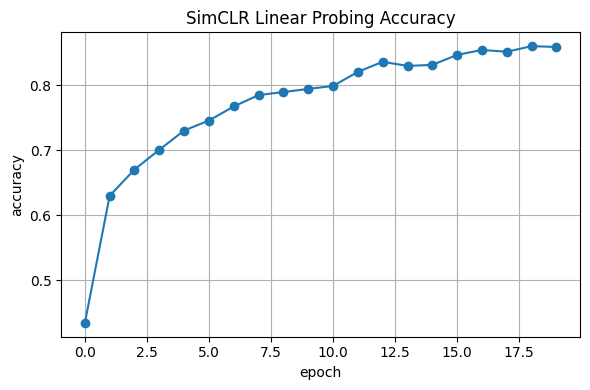

In [27]:
# plot accuracy
plot_metric(
    acc_hist_simclr_linear_prob,
    list(range(n_epochs)),
    ylabel='accuracy',
    xlabel='epoch',
    title='SimCLR Linear Probing Accuracy',
    save_path='outputs/simclr_acc_curve.png'
)

In [28]:
eval_acc_simclr = evaluate_linear_probe(simclr_model, eval_dl, len(eval_ds), device)

Test Accuracy: 0.7759
